In [24]:
import example_from_book.thinkdsp as tk
from scipy.stats import linregress
import matplotlib.pyplot as plt
import scipy.fftpack
import numpy as np

## Лабораторное задание 6.1

In [14]:
signal = sig_proc.UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)
noise.ys.shape

(16384,)

In [15]:
def dft_analysis_v1(ys, fs, ts):
    args = npy.outer(ts, fs)
    M = npy.cos(npy.pi * 2 * args)
    amps = npy.linalg.solve(M, ys)
    return amps

In [16]:
def dft_analysis_v2(ys, fs, ts):
    args = npy.outer(ts, fs)
    M = npy.cos(npy.pi * 2 * args)
    amps = npy.dot(M, ys) / 2
    return amps

In [17]:
def benchmark_transform(ns, func):
    results = []
    for N in ns:
        ts = (0.5 + npy.arange(N)) / N
        freqs = (0.5 + npy.arange(N)) / 2
        ys = noise.ys[:N]
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)

    timing_results = [result.best for result in results]
    return bests

In [21]:
def visualize_timing(ns, bests, label):
    mpl.plot(ns, bests, label=label)
    sig_proc.decorate(xscale='log', yscale='log')

    x = npy.log(ns)
    y = npy.log(bests)
    t = linregress(x, y)
    complexity_slope = t[0]

    print(f"Наклон для {label}: {slope:.3f}")
    return slope

139 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
492 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
1.26 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
4.17 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
14.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
Наклон для analyze1: 1.651


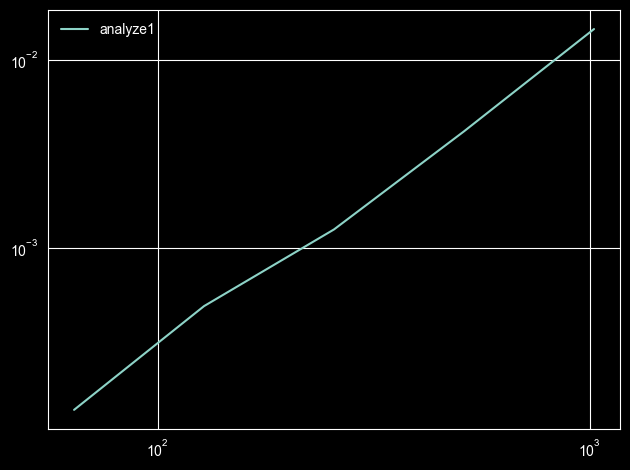

In [22]:
ns = 2 ** npy.arange(6, 11)

bests1 = run_speed_test(ns, analyze1)
slope1 = plot_bests(ns, bests1, 'analyze1')

17.8 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
113 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
364 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
1.09 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
4.56 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
Наклон для analyze2: 1.926


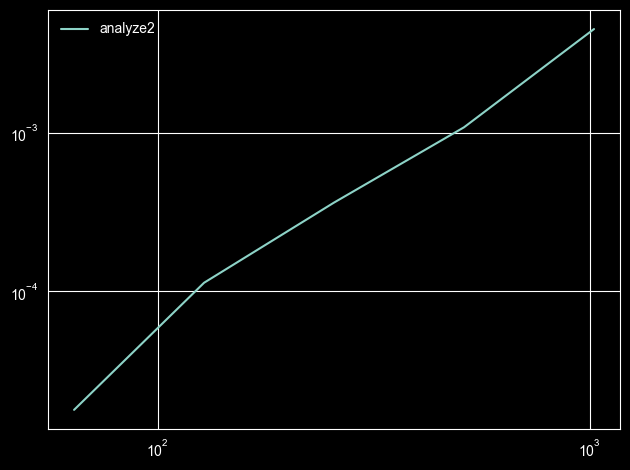

In [23]:
bests2 = run_speed_test(ns, analyze2)
slope2 = plot_bests(ns, bests2, 'analyze2')

In [35]:
def scipy_dct(ys, freqs, ts):
    return scipy.fftpack.dct(ys, type=3)

1.58 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000,000 loops each)
1.71 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000,000 loops each)
1.9 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000,000 loops each)
2.46 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
3.52 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
Наклон для scipy_dct: 0.283


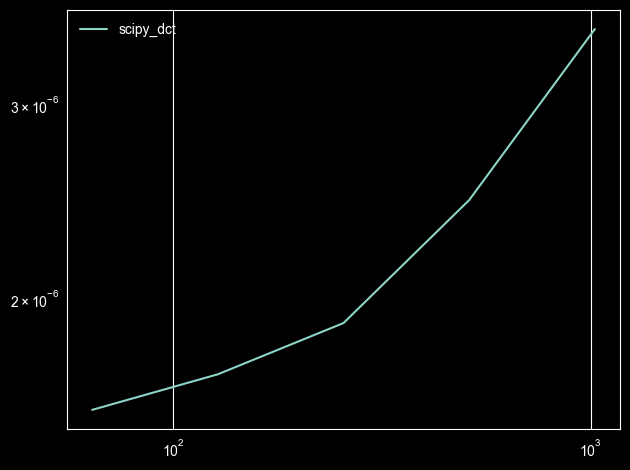

In [36]:
bests3 = run_speed_test(ns, scipy_dct)
slope3 = plot_bests(ns, bests3, 'scipy_dct')

In [28]:
def dct_iv(ys, freqs, ts):
    args = npy.outer(ts, freqs)
    M = npy.cos(2 * npy.pi * args)
    amps = npy.dot(M, ys) / 2
    return amps

18.4 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100,000 loops each)
153 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
526 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
1.36 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
5.54 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
Наклон для dct_iv: 1.963


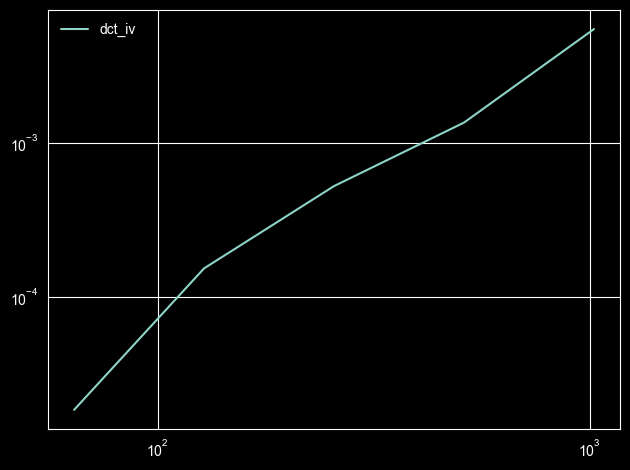

In [33]:
bests4 = run_speed_test(ns, dct_iv)
slope4 = plot_bests(ns, bests4, 'dct_iv')

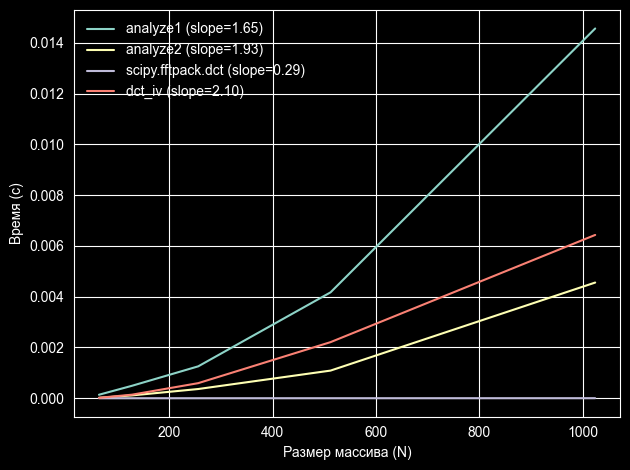

In [32]:
mpl.plot(ns, bests1, label=f'analyze1 (slope={slope1:.2f})')
mpl.plot(ns, bests2, label=f'analyze2 (slope={slope2:.2f})')
mpl.plot(ns, bests3, label=f'scipy.fftpack.dct (slope={slope3:.2f})')
mpl.plot(ns, bests4, label=f'dct_iv (slope={slope4:.2f})')
sig_proc.decorate(xlabel='Размер массива (N)', ylabel='Время (с)')

## Лабораторное задание 6.2

In [37]:
wave = sig_proc.read_wave('lab6.wav')
wave.make_audio()

In [38]:
segment = wave.segment(start=1.2, duration=0.5)
segment.normalize()
segment.make_audio()

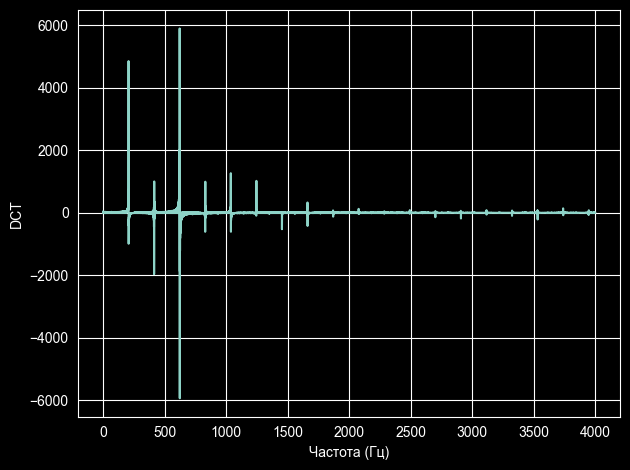

In [39]:
dct_coefficients = segment.make_dct()
seg_dct.plot(high=4000)
sig_proc.decorate(xlabel='Частота (Гц)', ylabel='DCT')

In [41]:
def compress(dct, thresh=0.1):
    count = 0
    total = len(dct.amps)

    for i, amp in enumerate(dct.amps):
        if npy.abs(amp) < thresh:
            dct.hs[i] = 0
            count += 1

    percent = 100 * count / total
    print(f"{count}/{total} ({percent:.2f}%)")
    return percent

In [42]:
for thresh in [0.01, 0.1, 0.5, 1.0, 2.0]:
    print(f"\nПорог = {thresh}:")
    seg_dct_copy = segment.make_dct()
    compress(seg_dct_copy, thresh=thresh)
    seg_compressed = seg_dct_copy.make_wave()


Порог = 0.01:
480/22050 (2.18%)

Порог = 0.1:
4511/22050 (20.46%)

Порог = 0.5:
12908/22050 (58.54%)

Порог = 1.0:
15296/22050 (69.37%)

Порог = 2.0:
17310/22050 (78.50%)


In [44]:
def make_dct_spectrogram(wave, seg_length=1024):
    window = npy.hamming(seg_length)
    i, j = 0, seg_length
    step = seg_length // 2

    spec_map = {}

    while j < len(wave.ys):
        segment = wave.slice(i, j)
        segment.window(window)

        t = (segment.start + segment.end) / 2
        spec_map[t] = segment.make_dct()

        i += step
        j += step

    return sig_proc.Spectrogram(spec_map, seg_length)

In [47]:
spectro = make_dct_spectrogram(wave, seg_length=1024)
len(spectro.spec_map)

1010

In [48]:
total_compression = []
for t, dct in sorted(spectro.spec_map.items()):
    percent = compress(dct, thresh=0.2)
    total_compression.append(percent)

1018/1024 (99.41%)
1016/1024 (99.22%)
1014/1024 (99.02%)
1017/1024 (99.32%)
1016/1024 (99.22%)
1017/1024 (99.32%)
1016/1024 (99.22%)
1020/1024 (99.61%)
1014/1024 (99.02%)
1005/1024 (98.14%)
1009/1024 (98.54%)
1015/1024 (99.12%)
1015/1024 (99.12%)
1016/1024 (99.22%)
1016/1024 (99.22%)
1015/1024 (99.12%)
1017/1024 (99.32%)
1020/1024 (99.61%)
1013/1024 (98.93%)
1017/1024 (99.32%)
1013/1024 (98.93%)
1017/1024 (99.32%)
1018/1024 (99.41%)
1015/1024 (99.12%)
1013/1024 (98.93%)
794/1024 (77.54%)
785/1024 (76.66%)
955/1024 (93.26%)
995/1024 (97.17%)
992/1024 (96.88%)
976/1024 (95.31%)
925/1024 (90.33%)
802/1024 (78.32%)
836/1024 (81.64%)
850/1024 (83.01%)
882/1024 (86.13%)
883/1024 (86.23%)
891/1024 (87.01%)
901/1024 (87.99%)
902/1024 (88.09%)
900/1024 (87.89%)
900/1024 (87.89%)
894/1024 (87.30%)
904/1024 (88.28%)
901/1024 (87.99%)
915/1024 (89.36%)
913/1024 (89.16%)
899/1024 (87.79%)
905/1024 (88.38%)
905/1024 (88.38%)
888/1024 (86.72%)
898/1024 (87.70%)
879/1024 (85.84%)
893/1024 (87.21%)
893

In [49]:
print(f"\nСредняя степень сжатия: {npy.mean(total_compression):.2f}%")
print(f"Минимальная: {npy.min(total_compression):.2f}%")
print(f"Максимальная: {npy.max(total_compression):.2f}%")


Средняя степень сжатия: 82.15%
Минимальная: 65.92%
Максимальная: 99.61%


In [51]:
wave_compressed = spectro.make_wave()
wave_compressed.make_audio()

In [52]:
test_thresholds = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
waves = {}

for thresh in test_thresholds:
    print(f"\nПорог: {thresh}")
    spectro_test = make_dct_spectrogram(wave.segment(duration=2.0), seg_length=1024)

    for t, dct in spectro_test.spec_map.items():
        compress(dct, thresh=thresh)

    wave_test = spectro_test.make_wave()
    waves[thresh] = wave_test.make_audio()


Порог: 0.01
276/1024 (26.95%)
280/1024 (27.34%)
275/1024 (26.86%)
283/1024 (27.64%)
262/1024 (25.59%)
246/1024 (24.02%)
268/1024 (26.17%)
273/1024 (26.66%)
263/1024 (25.68%)
249/1024 (24.32%)
263/1024 (25.68%)
274/1024 (26.76%)
277/1024 (27.05%)
293/1024 (28.61%)
266/1024 (25.98%)
263/1024 (25.68%)
259/1024 (25.29%)
307/1024 (29.98%)
253/1024 (24.71%)
274/1024 (26.76%)
276/1024 (26.95%)
263/1024 (25.68%)
287/1024 (28.03%)
254/1024 (24.80%)
218/1024 (21.29%)
180/1024 (17.58%)
163/1024 (15.92%)
206/1024 (20.12%)
226/1024 (22.07%)
227/1024 (22.17%)
215/1024 (21.00%)
203/1024 (19.82%)
172/1024 (16.80%)
183/1024 (17.87%)
168/1024 (16.41%)
209/1024 (20.41%)
203/1024 (19.82%)
182/1024 (17.77%)
209/1024 (20.41%)
198/1024 (19.34%)
219/1024 (21.39%)
212/1024 (20.70%)
227/1024 (22.17%)
199/1024 (19.43%)
203/1024 (19.82%)
221/1024 (21.58%)
186/1024 (18.16%)
234/1024 (22.85%)
190/1024 (18.55%)
205/1024 (20.02%)
224/1024 (21.88%)
192/1024 (18.75%)
230/1024 (22.46%)
198/1024 (19.34%)
216/1024 (21.09

## Лабораторное задание 6.3

In [57]:
signal = sig_proc.SquareSignal(freq=500, offset=0)
wave = signal.make_wave(duration=0.5, framerate=40000)
wave.make_audio()

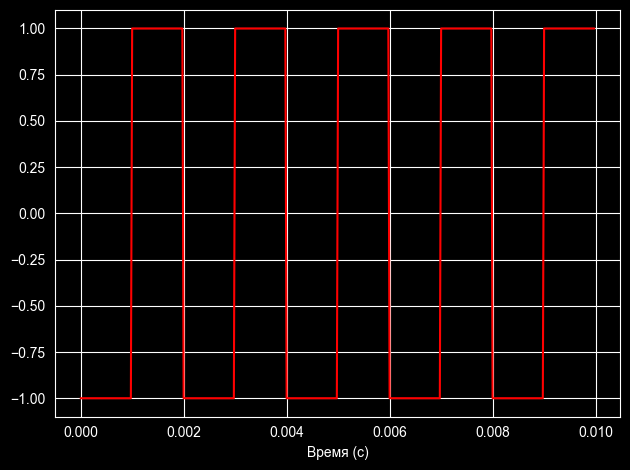

In [60]:
wave.segment(duration=0.01).plot(color='red')
sig_proc.decorate(xlabel='Время (с)')

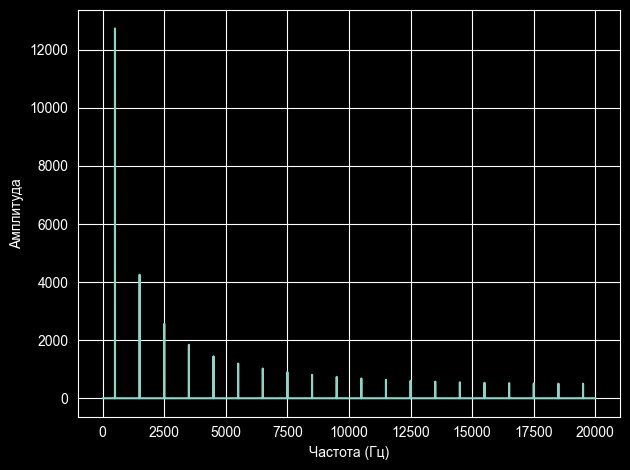

In [61]:
spectrum = wave.make_spectrum()
spectrum.plot()
sig_proc.decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

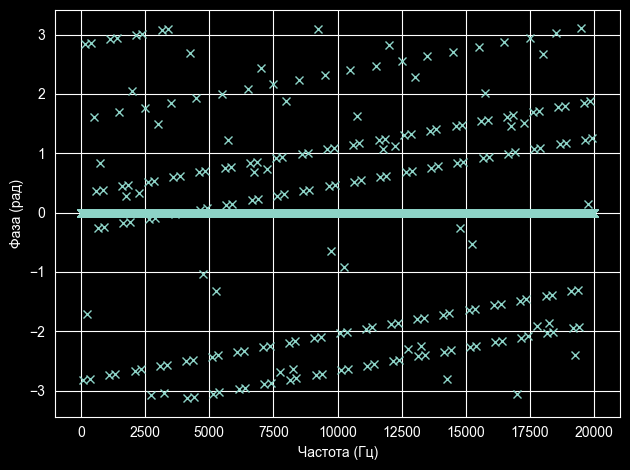

In [63]:
def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = npy.nan
    mpl.plot(spectrum.fs, angles, 'x')
    sig_proc.decorate(xlabel='Частота (Гц)', ylabel='Фаза (рад)')

plot_angle(spectrum, thresh=0)

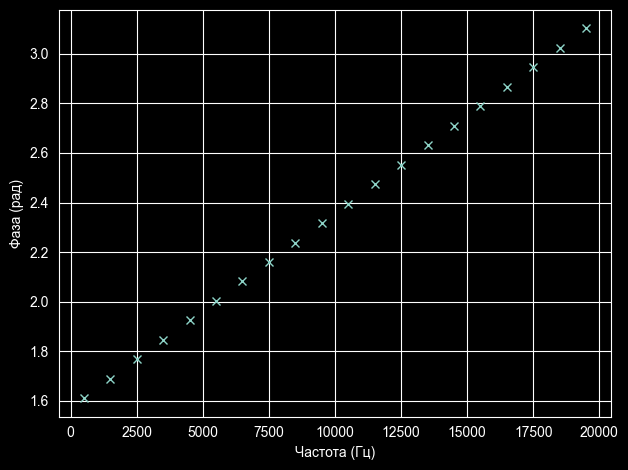

In [64]:
plot_angle(spectrum, thresh=1)

In [67]:
def plot_three(spectrum, thresh=1):
    mpl.figure(figsize=(10, 4))
    mpl.subplot(1,3,1)
    spectrum.plot()
    mpl.subplot(1,3,2)
    plot_angle(spectrum, thresh=thresh)
    mpl.subplot(1,3,3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot(color='red')
    display(wave.make_audio())

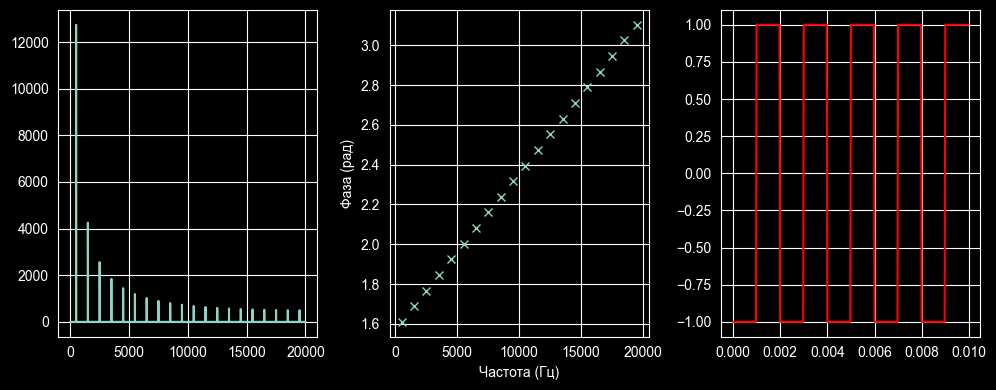

In [68]:
plot_three(spectrum)

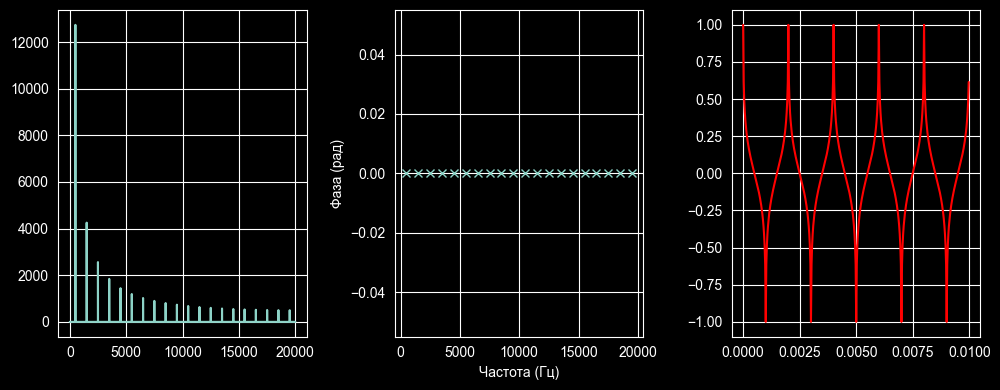

In [69]:
def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res

spectrum2 = zero_angle(spectrum)
plot_three(spectrum2)

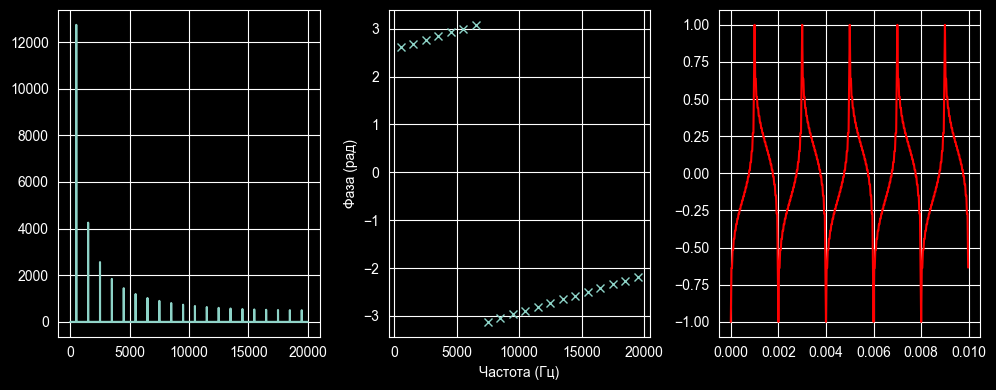

In [70]:
def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= npy.exp(1j * offset)
    return res

spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3)

In [71]:
def random_angle(spectrum):
    res = spectrum.copy()
    angles = npy.random.uniform(0, npy.pi * 2, len(spectrum))
    res.hs *= npy.exp(1j * angles)
    return res

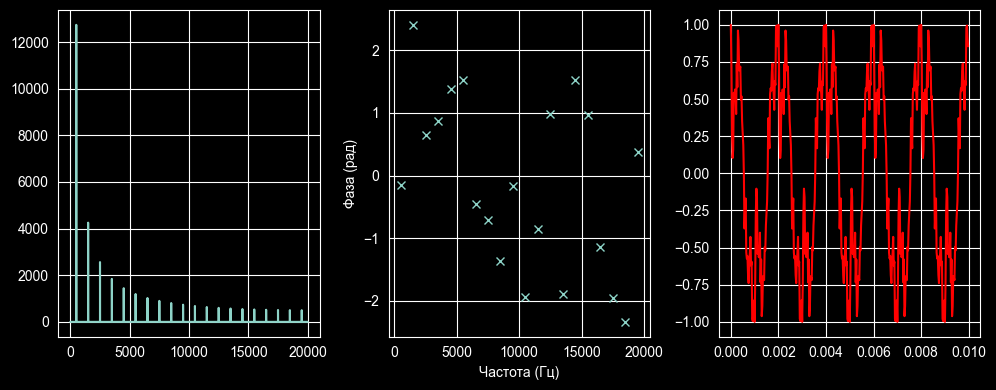

In [72]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4)